Aluna: Nathália Rayanne Lima Araújo

# Regressão Logística - 3 classes

Este exemplo utiliza um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/mrsimple07/student-exam-performance-prediction).

## Importação das bibliotecas

In [3]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F

from IPython import display

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/student_exam_data_new.csv')
df.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


## Dataset: Leitura, normalização e visualização dos dados

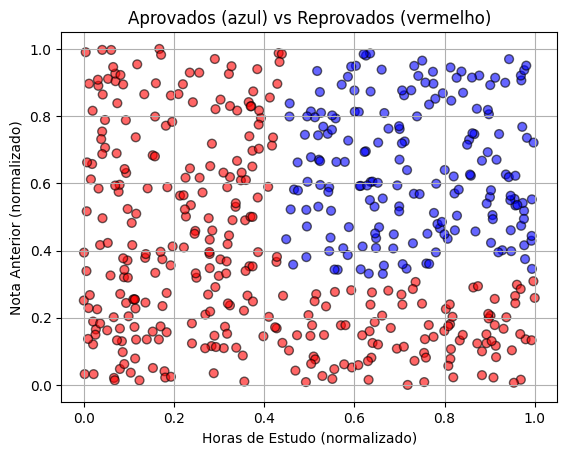

In [11]:
X  = df[['Study Hours', 'Previous Exam Score']].values
Y  = df['Pass/Fail'].values

Xc = X - X.min(axis=0)
Xc = Xc / Xc.max(axis=0)

colors = np.array(['r', 'b'])   # vermelho=reprovado, azul=aprovado
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y], alpha=0.6, edgecolors='k', s=40)
plt.xlabel('Horas de Estudo (normalizado)')
plt.ylabel('Nota Anterior (normalizado)')
plt.title('Aprovados (azul) vs Reprovados (vermelho)')
plt.grid(True)
plt.show()

### Prepara os dados para o PyTorch

In [12]:
X_tensor = torch.FloatTensor(Xc)  # Entrada é FloatTensor
Y_tensor = torch.LongTensor(Y)    # Classe é LongTensor

In [13]:
Y_tensor

tensor([0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
        1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
        0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
        1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
        0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,

## Construindo o modelo da rede

A saída da rede é composta por um neurônio para cada classe. A saída é denominada *scores* ou logitos:

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLogisticaRede_2_3.png)

In [14]:
model = nn.Linear(2,2)  # 2 entradas e 2 saídas

In [15]:
model.state_dict()

OrderedDict([('weight',
              tensor([[-0.1742, -0.1328],
                      [ 0.6554, -0.5789]])),
             ('bias', tensor([0.3071, 0.0222]))])

### Fazendo um predict

In [16]:
out = model(Variable(X_tensor[:4,:])) # 4 amostras
out

tensor([[ 0.1494, -0.1361],
        [ 0.0694,  0.3404],
        [ 0.1382,  0.3271],
        [ 0.0944, -0.0547]], grad_fn=<AddmmBackward0>)

In [17]:
oo = F.softmax(out,dim=1)
oo

tensor([[0.5709, 0.4291],
        [0.4327, 0.5673],
        [0.4529, 0.5471],
        [0.5372, 0.4628]], grad_fn=<SoftmaxBackward0>)

### Calculando as probabilidades com Softmax

- [Wikipedia:Softmax_function](https://en.wikipedia.org/wiki/Softmax_function)

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/softmax.png)

In [18]:
F.softmax(out,dim=1)*100

tensor([[57.0896, 42.9104],
        [43.2662, 56.7338],
        [45.2911, 54.7089],
        [53.7219, 46.2781]], grad_fn=<MulBackward0>)

### Predição da classe

In [19]:
prob,y_pred = torch.max(F.softmax(out,dim=1),dim=1)
print(y_pred)
print(prob)

tensor([0, 1, 1, 0])
tensor([0.5709, 0.5673, 0.5471, 0.5372], grad_fn=<MaxBackward0>)


## Treinamento

### Classe para visualização dinâmica

In [20]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

def predict_prob(model, inputs):
    outputs = model(Variable(inputs))
    outputs = F.softmax(outputs,dim=1)
    predicts, _ = torch.max(outputs, 1)

    return predicts.data.numpy()

class MyPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(12, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 3, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.set_title('Perda x Época')
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 3, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)
        self.ax2.set_title('Fronteiras de decisão')

        self.ax3 = self.fig.add_subplot(1, 3, 3)
        self.ax3.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax3.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax3.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax3.set_ylabel('Largura da Sepala')#,fontsize=28)
        self.ax3.set_title('Máxima probabilidade')

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                #Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
                Zc = predict(self.model,torch.FloatTensor(self.X_grid))
                Zc = Zc.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Zc, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                Zp = predict_prob(self.model,torch.FloatTensor(self.X_grid))
                Zp = Zp.reshape(self.xx.shape)

                self.ax3.pcolormesh(self.xx, self.yy, Zp, cmap=plt.cm.magma)
                colors = np.array(['r','y','b'])
                self.ax3.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

### Laço principal de treinamento da Regressão Logística por Softmax

In [21]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

Final loss: 0.26929768919944763


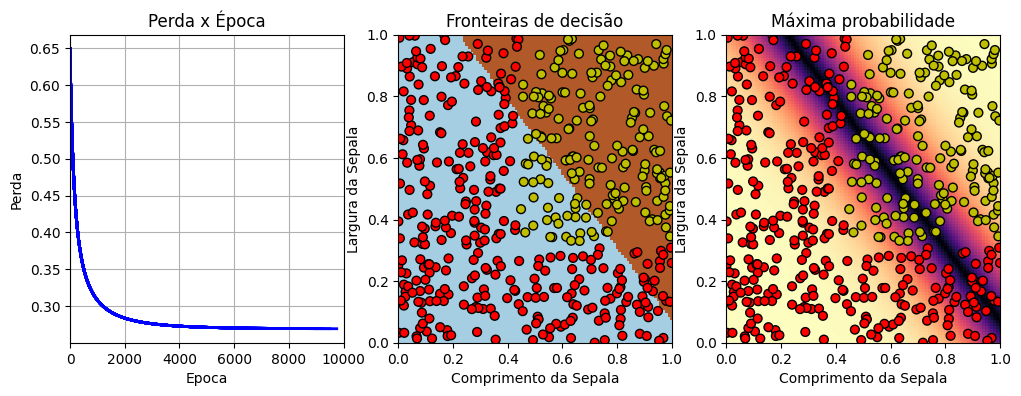

In [22]:
nb_epoch = 10000

#Definindo o plotter
my_plot = MyPlotter(model, Xc, Y, nb_epoch)

losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    # calcula a perda
    loss = criterion(output, Variable(Y_tensor))

    # Faz o backpropagation para calcular os gradientes e otimizar parâmetros
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data.item())

    my_plot.on_epoch_end(i, {'loss': loss.data.item()});
    final_loss = loss.data.item()

print('Final loss:', final_loss)

## Avaliação

### Parâmetros após treinamento

In [23]:
model.state_dict()

OrderedDict([('weight',
              tensor([[-4.6605, -4.4608],
                      [ 5.1417,  3.7491]])),
             ('bias', tensor([ 5.3577, -5.0284]))])

### Salvando os parâmetros treinados

In [24]:
os.makedirs('../models',exist_ok=True)
torch.save(model.state_dict(), '../models/RegrLog_Student.pt')

In [25]:
! ls ../models/

RegrLog_Student.pt


In [26]:
nn.init.constant(model.weight,0)
model.state_dict()

/tmp/ipykernel_5438/952960416.py:1: FutureWarning: `nn.init.constant` is now deprecated in favor of `nn.init.constant_`.
  nn.init.constant(model.weight,0)


OrderedDict([('weight',
              tensor([[0., 0.],
                      [0., 0.]])),
             ('bias', tensor([ 5.3577, -5.0284]))])

### Recuperando os pesos salvos

In [27]:
param_saved = torch.load('../models/RegrLog_Student.pt')
model.load_state_dict(param_saved)
model.state_dict()

OrderedDict([('weight',
              tensor([[-4.6605, -4.4608],
                      [ 5.1417,  3.7491]])),
             ('bias', tensor([ 5.3577, -5.0284]))])

### Exatidão (acurácia) do classificador

Acurácia indica o número de acertos sobre o número total de amostras

In [28]:
Y_pred = predict(model, X_tensor)
accuracy = (Y_pred == Y).mean()
print('Training Accuracy: ', accuracy)

Training Accuracy:  0.868


### Matriz de confusão

In [29]:
import pandas as pd
pd.crosstab(Y_pred, Y)

col_0,0,1
row_0,,
0,284,34
1,32,150


## Atividades

### Perguntas:

1. Observe que se após o treinamento, a célula for executada novamente, ela continua utilizando os parâmetros treinados até sua última execução. O que é preciso fazer para que o treinamento comece deste o início, como da primeira vez que foi executado?

2. Experimente refazer o treinamento com diferentes valores de learning rate

Respostas:

1)

Quando o laço de treinamento é executado novamente sem recriar o modelo, o PyTorch continua utilizando os pesos já treinados anteriormente. Isso acontece porque os parâmetros do modelo permanecem armazenados na memória durante toda a sessão do notebook, fazendo com que o treinamento continue do ponto em que parou, como se fossem épocas adicionais.

Para reiniciar o treinamento desde o início, com novos pesos aleatórios, é necessário recriar tanto o modelo quanto o otimizador antes de executar novamente o laço de treinamento:

"Executar ANTES do laço de treinamento:

model = nn.Linear(2, 2)   
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

Logo após, o treinamento normalmente:

for i in range(nb_epoch):
"

Dessa forma, o modelo volta ao estado inicial, permitindo que o treinamento seja realizado novamente desde o começo, como na primeira execução.

2.

Ao refazer o treinamento com diferentes valores de learning rate, é possível observar como essa taxa influencia diretamente a velocidade e a estabilidade do aprendizado da rede neural. Os valores muito pequenos de learning rate fazem com que o treinamento ocorra de maneira lenta, exigindo mais épocas para que a função de perda diminua significativamente. Em contrapartida, valores muito altos podem causar oscilações ou até impedir a convergência do modelo, pois os pesos passam a ser atualizados com passos excessivamente grandes. Já valores intermediários tendem a apresentar melhor desempenho, permitindo uma redução mais rápida e estável da perda ao longo do treinamento.

### Exercícios:

1. Observando o gráfico de máxima probabilidade, responda:
    1. Qual é a amostra classificada corretamente, com maior probabilidade?
    
    2. Qual é a amostra classificada erradamente, com maior probabilidade?
    
    3. Qual é a amostra classificada corretamente, com menor probabilidade?
    4. Qual é a amostra classificada erradamente, com menor probabilidade?
2. Quantos parâmetros possui esta rede? Quantos são da camada densa e quantos são de bias?
3. Quantas entradas e quantas saídas esta rede possui?
4. Como se pode calcular a acurácia a partir da matriz de confusão?
5. O que faz a função `torch.max`? Quantos parâmetros ela retorna e quais seus significados?
    - http://pytorch.org/docs/master/torch.html?highlight=torch%20max#torch.max

Respostas:

1)

1.1)
Amostra classificada corretamente com maior probabilidade:
É o ponto mais escuro dentro da região da sua própria classe. O modelo acertou com alta confiança.

1.2)
Amostra classificada erradamente com maior probabilidade:
É o ponto mais escuro fora da região correta. O modelo errou, mas estava muito confiante.

1.3)
Amostra classificada corretamente com menor probabilidade:
É um ponto claro dentro da região correta. O modelo acertou, mas com pouca confiança.

1.4)
Amostra classificada erradamente com menor probabilidade:
É um ponto claro fora da região correta. O modelo errou e também demonstrou pouca confiança na previsão.

2)
Esta rede possui 6 parâmetros no total.

4 parâmetros pertencem à camada densa (weights), pois o modelo possui 2 entradas e 2 saídas:
2×2=4

2 parâmetros são de bias, sendo um para cada neurônio de saída.

Assim, o total de parâmetros da rede é:

4+2=6

3)

Entradas: 2 ; Study Hours (horas de estudo) e Previous Exam Score (nota anterior)
Saídas: 2 ; Logit para Classe 0 (Reprovado) e Logit para Classe 1 (Aprovado)

4)

A acurácia é calculada somando os valores da diagonal principal da matriz de confusão, que representam os acertos do modelo, e dividindo pelo total de amostras.

No exemplo:

Acertos:
195+270=465

Total de amostras:
195+15+20+270=500

Cálculo da acurácia:
465/500 =0.93 = 93%
	​
Portanto, o modelo possui acurácia de 93%, indicando que acertou 465 das 500 amostras.

5)

A função torch.max(tensor, dim) encontra o valor máximo de um tensor ao longo de uma dimensão específica. No contexto de classificação, ela é usada para decidir qual classe o
modelo escolhe;

## Principais aprendizados

Os experimentos realizados permitiram compreender conceitosda regressão logística e do treinamento de redes neurais no *PyTorch*. Esse tipo modelo é utilizado para classificação, prevendo probabilidades de cada classe por meio da função *Softmax*. Também foi possível entender que o número de saídas da rede depende diretamente da quantidade de classes do problema.

Além disso, para reiniciar o treinamento corretamente, é necessário recriar o modelo e o otimizador, já que o *PyTorch* mantém os pesos treinados em memória. Outro ponto importante foi entender a influência do learning rate no aprendizado: valores muito baixos tornam o treinamento lento, enquanto valores muito altos podem impedir a convergência do modelo.

Os testes também mostraram que a função *CrossEntropyLoss* já aplica internamente a *Softmax*, evitando a necessidade de utilizá-la antes do cálculo da perda. Por fim, a matriz de confusão demonstrou ser uma ferramenta essencial para avaliar o desempenho do modelo, pois além de calcular a acurácia, permite identificar quais classes estão sendo confundidas durante as previsões.